In [7]:
import marimo as mo
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from itertools import combinations
from tqdm import tqdm
import os
import re
import yaml
from torchgeodemo import autoencoder_train_latent
import torch
#notebook to rest reconstruction error of PCA

# #load the census data
# def populate_data_table(filepath: str) -> pd.DataFrame:
#     print("Populating data table from files in", filepath)
#     data_table = None  # Initialize data_table outside the loop

#     for file in tqdm(os.listdir(filepath), desc="Processing files", unit="file"):
#         df = pd.read_csv(filepath + "/" + file, index_col="OA")
#         if data_table is None:
#             data_table = df  # Initialize data_table with the first file encountered
#         else:
#             # Merge on index
#             data_table = data_table.merge(df, left_index=True, right_index=True, how="outer")
#     return data_table

# # Load the data
# data_path = "../data/uk_census/"
# data_table = populate_data_table(data_path)

# #drop the totals (columns ending 001)
# data_table = data_table.loc[:, ~data_table.columns.str.endswith("001")]

# #save the data
# data_table.to_csv("../data/uk_census_all.csv")

# #load the data
data_table = pd.read_csv("../data/uk_census_all.csv", index_col=0)

random_seed_number = 20210321  # 2021 UK Census date used as random seed
def set_random_seeds(seed):
    # """Set random seeds for reproducibility."""
    torch.manual_seed(seed)  # Set seed for PyTorch
    # np.random.seed(seed)  # Set seed for NumPy
    # random.seed(seed)  # Set seed for Python's random module

    # # If using a GPU, set seeds for CUDA as well
    # torch.cuda.manual_seed(seed)
    # torch.cuda.manual_seed_all(seed)  # For multi-GPU setups

    # # Ensure deterministic behavior on GPU
    # torch.backends.cudnn.deterministic = True  # Make sure CUDA uses deterministic algorithms
    # torch.backends.cudnn.benchmark = False  # Avoid using CUDA's autotuning for performance (slower, but more reproducible)

# Set the seed
set_random_seeds(seed=random_seed_number)
epochs = 60
run_name = "latent_check"
bottleneck_sizes = [4]

WORKING_DIR = "../ukcensus/latentsizecheck"
os.makedirs(WORKING_DIR, exist_ok=True)
OUTPUT_DIR = "../ukcensus/latentsizecheck/yamls"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [9]:
# Set the seed
set_random_seeds(seed=random_seed_number)
# Output directory for generated YAMLs


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "census_geodemo",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": run_name,
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.5,
        "use_covariance_loss": False,
        "encoder": {
            "sizes": [256, 128,96],
            "activation": "ReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01,
            }
        },
        "decoder": {
            "sizes": [96, 128,256],
            "activation": "LeakyReLU"
        }
    }
}

# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["nickname"] = f"bottleneck_{_latent_size}"
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = _latent_size

    config_path = os.path.join(OUTPUT_DIR, f"config_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

print(f"Generated YAML configurations in {OUTPUT_DIR}")

for _latent_size in bottleneck_sizes:
    yaml_path = f"{OUTPUT_DIR}/config_{_latent_size}.yaml"
    autoencoder_train_latent.main(yaml_path, create_latent=True,save_reco_error=True, verbose=True)

Generated YAML configurations in ../ukcensus/latentsizecheck/yamls

geodemo_config={'autoencoder': {'batch_size': 0.5, 'decoder': {'activation': 'LeakyReLU', 'sizes': [96, 128, 256]}, 'encoder': {'activation': 'ReLU', 'sizes': [256, 128, 96], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'use_covariance_loss': False, 'version': 'latent_check'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/latentsizecheck'}


ae_args={'verbose': True, 'encoder_activation': 'ReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'use_covariance_loss': False, 'decoder_sizes': [96, 128, 256, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=2

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 94.2 K | train
2 | decoder       | MLP     | 94.3 K | train
--------------------------------------------------
188 K     Trainable params
0         Non-trainable params
188 K     Total params
0.754     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/var/home/ogoodwin/Projects/geoencoder/.venv/lib64/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=39` in the `DataLoader` to improve performance.
/var/home/ogoodwin/Project

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=60` reached.


Reconstructed outputs saved to ../ukcensus/latentsizecheck/census_geodemo__bottleneck_4_vlatent_check__reconstructed_outputs.csv


In [5]:
import torch
print(torch.cuda.is_available())  # Should print True
print(torch.cuda.device_count())  # Should print >0
print(torch.cuda.current_device())  # Should print 0 or higher
print(torch.cuda.get_device_name(0))  # Check your GPU model


True
2
0
NVIDIA RTX 6000 Ada Generation


In [7]:
x = torch.randn(1000, 1000).to("cuda")
y = x @ x  # Matrix multiplication
print(y.device)  # Should print cuda:0


cuda:0


In [9]:
set_random_seeds(seed=random_seed_number)


# Define the base YAML structure as a dictionary
BASE_YAML = {
    "data": {
        "source": "../data/uk_census_all.csv",
        "nickname": "census_geodemo_cov",
        "id_col": "OA"
    },
    "working_dir": WORKING_DIR,
    "autoencoder": {
        "nickname": "bottleneck_PLACEHOLDER",
        "version": run_name,
        "save_latent": "csv",
        "max_epochs": epochs,
        "batch_size": 0.01,
        "encoder": {
            "sizes": [256, 128,96],
            "activation": "LeakyReLU",
            "sparse": {
                "topk_k": "PLACEHOLDER",
                "sparsity_loss_weight": 0.01
            }
        },
        "decoder": {
            "sizes": [96, 128,256],
            "activation": "LeakyReLU"
        }
    }
}


# Generate YAML files with varying latent space sizes
for _latent_size in bottleneck_sizes:
    yaml_config = BASE_YAML.copy()
    yaml_config["autoencoder"]["nickname"] = f"bottleneck_{_latent_size}"
    yaml_config["autoencoder"]["encoder"]["sparse"]["topk_k"] = _latent_size

    config_path = os.path.join(OUTPUT_DIR, f"config_cov_{_latent_size}.yaml")
    with open(config_path, "w") as yaml_file:
        yaml.dump(yaml_config, yaml_file, default_flow_style=False)

print(f"Generated YAML configurations in {OUTPUT_DIR}")

for _latent_size in bottleneck_sizes:
    yaml_path = f"{OUTPUT_DIR}/config_cov_{_latent_size}.yaml"
    autoencoder_train_latent.main(yaml_path, create_latent=True,save_reco_error=True, verbose=True)

Generated YAML configurations in ../ukcensus/latentsizecheck/yamls

geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [96, 128, 256]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [256, 128, 96], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 4}}, 'max_epochs': 60, 'nickname': 'bottleneck_4', 'save_latent': 'csv', 'version': 'latent_check'}, 'data': {'id_col': 'OA', 'nickname': 'census_geodemo_cov', 'source': '../data/uk_census_all.csv'}, 'working_dir': '../ukcensus/latentsizecheck'}


ae_args={'verbose': True, 'encoder_activation': 'LeakyReLU', 'encoder_sparse': True, 'encoder_sparse_topk_k': 4, 'decoder_sizes': [96, 128, 256, 190], 'decoder_activation': 'LeakyReLU'}

AutoEncoder(
  (dcc_criterion): MSELoss()
  (encoder): MLP(
    (mlp): Sequential(
      (0): Linear(in_features=190, out_features=256, bias=True)
      (1): LeakyReLU(negative_slope=0.01)
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): L

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 94.2 K | train
2 | decoder       | MLP     | 94.3 K | train
--------------------------------------------------
188 K     Trainable params
0         Non-trainable params
188 K     Total params
0.754     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 45.50it/s, v_num=4_5, recon_loss_step=0.0182, covariance_loss_step=0.000219, sparsity_loss_step=0.0247, train_loss_step=0.0186, recon_loss_epoch=0.0183, covariance_loss_epoch=0.000181, sparsity_loss_epoch=0.0247, train_loss_epoch=0.0187]

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 45.21it/s, v_num=4_5, recon_loss_step=0.0182, covariance_loss_step=0.000219, sparsity_loss_step=0.0247, train_loss_step=0.0186, recon_loss_epoch=0.0183, covariance_loss_epoch=0.000181, sparsity_loss_epoch=0.0247, train_loss_epoch=0.0187]
Reconstruction errors saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_4_vlatent_check__recon_error.csv
Original inputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_4_vlatent_check__original_inputs.csv
Reconstructed outputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_4_vlatent_check__reconstructed_outputs.csv

geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [96, 128, 256]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [256, 128, 96], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 8}}, 'max_epochs': 60, 'nickname': 'bottleneck_8', 'save_latent': 'csv', 'version': 'latent_check'}, 'd

...

Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 43.81it/s, v_num=2_3, recon_loss_step=0.0125, covariance_loss_step=0.00018, sparsity_loss_step=0.0324, train_loss_step=0.013, recon_loss_epoch=0.0122, covariance_loss_epoch=0.00018, sparsity_loss_epoch=0.0324, train_loss_epoch=0.0127]
Reconstruction errors saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_8_vlatent_check__recon_error.csv
Original inputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_8_vlatent_check__original_inputs.csv
Reconstructed outputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_8_vlatent_check__reconstructed_outputs.csv

geodemo_config={'autoencoder': {'batch_size': 0.01, 'decoder': {'activation': 'LeakyReLU', 'sizes': [96, 128, 256]}, 'encoder': {'activation': 'LeakyReLU', 'sizes': [256, 128, 96], 'sparse': {'sparsity_loss_weight': 0.01, 'topk_k': 16}}, 'max_epochs': 60, 'nickname': 'bottleneck_16', 'save_latent': 'csv', 'version': 'latent_check'}, 'da

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name          | Type    | Params | Mode 
--------------------------------------------------
0 | dcc_criterion | MSELoss | 0      | train
1 | encoder       | MLP     | 94.2 K | train
2 | decoder       | MLP     | 94.3 K | train
--------------------------------------------------
188 K     Trainable params
0         Non-trainable params
188 K     Total params
0.754     Total estimated model params size (MB)
18        Modules in train mode
0         Modules in eval mode
/home/ogoodwin/geoencoder/.venv/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=21` in the `DataLoader` to improve performance.


Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 40.15it/s, v_num=0_1, recon_loss_step=0.00821, covariance_loss_step=0.000212, sparsity_loss_step=0.0445, train_loss_step=0.00887, recon_loss_epoch=0.00807, covariance_loss_epoch=0.000212, sparsity_loss_epoch=0.0448, train_loss_epoch=0.00873]

`Trainer.fit` stopped: `max_epochs=60` reached.


Epoch 59: 100%|██████████| 100/100 [00:02<00:00, 39.88it/s, v_num=0_1, recon_loss_step=0.00821, covariance_loss_step=0.000212, sparsity_loss_step=0.0445, train_loss_step=0.00887, recon_loss_epoch=0.00807, covariance_loss_epoch=0.000212, sparsity_loss_epoch=0.0448, train_loss_epoch=0.00873]
Reconstruction errors saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_16_vlatent_check__recon_error.csv
Original inputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_16_vlatent_check__original_inputs.csv
Reconstructed outputs saved to ../ukcensus/latentsizecheck/census_geodemo_cov__bottleneck_16_vlatent_check__reconstructed_outputs.csv


In [4]:
n_features = data_table.shape[1]
data = data_table

# Fit PCA once with the maximum number of components
pca = PCA(n_components=n_features - 1)
transformed = pca.fit_transform(data)

Computing errors: 100%|██████████| 8/8 [01:00<00:00,  7.56s/it]


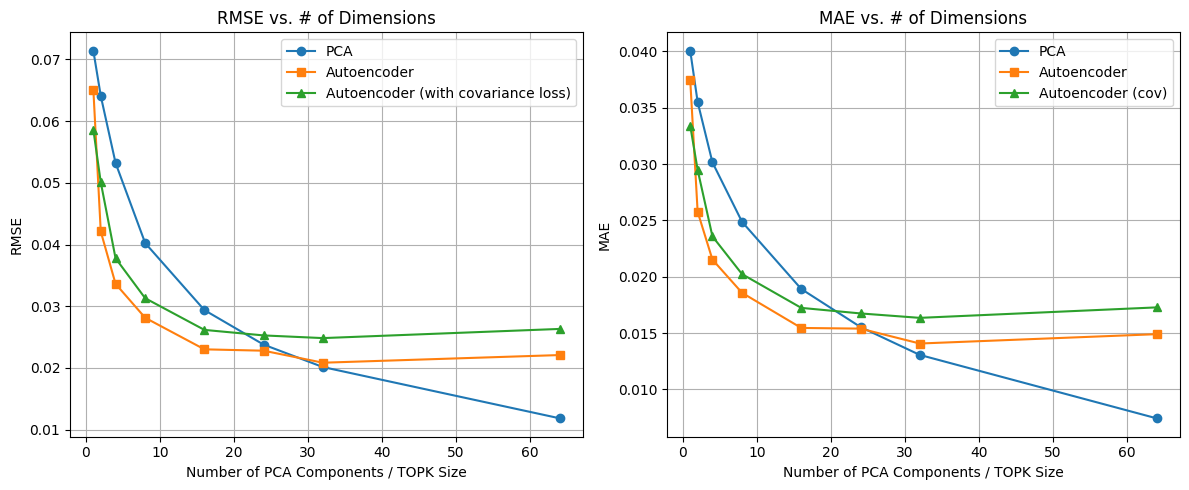

In [10]:
# Lists to store RMSE and MAE
rmse_pca, rmse_ae, rmse_cov_ae= [], [], []
mae_pca, mae_ae , mae_cov_ae= [], [], []

# Iterate over different bottleneck sizes
for n in tqdm(bottleneck_sizes[:-1], desc="Computing errors"):
    # PCA reconstruction
    reconstructed_pca = (transformed[:, :n] @ pca.components_[:n]) + pca.mean_
    error_pca = data - reconstructed_pca
    rmse_pca.append(np.sqrt(np.mean(error_pca ** 2)))
    mae_pca.append(np.mean(np.abs(error_pca)))

    # Autoencoder reconstruction
    reconstructed_ae = pd.read_csv(
        f"{WORKING_DIR}/census_geodemo__bottleneck_{n}_v{run_name}__reconstructed_outputs.csv", 
        index_col="ID"
    )
    error_ae = data - reconstructed_ae
    rmse_ae.append(np.sqrt(np.mean(error_ae ** 2)))
    mae_ae.append(np.mean(np.abs(error_ae)))

    # Autoencoder reconstruction without covariance loss
    reconstructed_cov_ae = pd.read_csv(
        f"{WORKING_DIR}/census_geodemo_cov__bottleneck_{n}_v{run_name}__reconstructed_outputs.csv", 
        index_col="ID"
    )
    error_cov_ae = data - reconstructed_cov_ae
    rmse_cov_ae.append(np.sqrt(np.mean(error_cov_ae ** 2)))
    mae_cov_ae.append(np.mean(np.abs(error_cov_ae)))

# Plot RMSE
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(bottleneck_sizes[:-1], rmse_pca, marker='o', label="PCA")
plt.plot(bottleneck_sizes[:-1], rmse_ae, marker='s', label="Autoencoder")
plt.plot(bottleneck_sizes[:-1], rmse_cov_ae, marker='^', label="Autoencoder (with covariance loss)")
plt.xlabel("Number of PCA Components / TOPK Size")
plt.ylabel("RMSE")
plt.title("RMSE vs. # of Dimensions")
plt.legend()
plt.grid()

# Plot MAE
plt.subplot(1, 2, 2)
plt.plot(bottleneck_sizes[:-1], mae_pca, marker='o', label="PCA")
plt.plot(bottleneck_sizes[:-1], mae_ae, marker='s', label="Autoencoder")
plt.plot(bottleneck_sizes[:-1], mae_cov_ae, marker='^', label="Autoencoder (cov)")
plt.xlabel("Number of PCA Components / TOPK Size")
plt.ylabel("MAE")
plt.title("MAE vs. # of Dimensions")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()